# **Pie Charts**

- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.

## Objectives

In this lab you will perform the following:

-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.

## Setup: Downloading and Loading the Data
**Install the libraries**

In [1]:
#!pip install pandas
#!pip install matplotlib

**Download and Load the Data**

To start, download and load the dataset into a `pandas` DataFrame.

In [3]:
# If wget does not work on Windows/Jupyter,
# directly load the dataset using the URL

import pandas as pd
import matplotlib.pyplot as plt

# Dataset URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load dataset into DataFrame
df = pd.read_csv(file_url)

# Display first 5 rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts

##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With

In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.

In [4]:
# Select the DatabaseWantToWorkWith column and remove missing values

db_df = df[['DatabaseWantToWorkWith']].dropna()

# Display first few rows
print(db_df.head())

       DatabaseWantToWorkWith
1                  PostgreSQL
2  Firebase Realtime Database
3    MongoDB;MySQL;PostgreSQL
4           PostgreSQL;SQLite
5             Cloud Firestore


In [5]:
# Split multiple databases into separate rows

db_exploded = db_df.assign(
    DatabaseWantToWorkWith=
    db_df['DatabaseWantToWorkWith'].str.split(';')
).explode('DatabaseWantToWorkWith')

In [6]:
# Count frequency of each database

top_databases = (
    db_exploded['DatabaseWantToWorkWith']
    .value_counts()
    .head(5)
)

print(top_databases)

DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


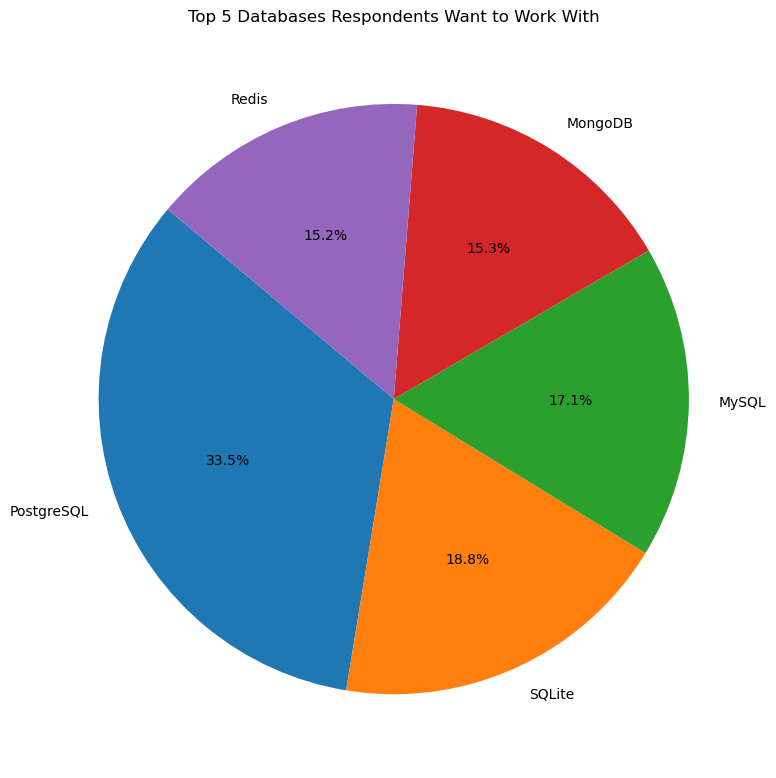

In [7]:
# Create pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_databases.values,
    labels=top_databases.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 Databases Respondents Want to Work With')

plt.tight_layout()
plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.

In [8]:
# Select the DevType column and remove missing values

dev_df = df[['DevType']].dropna()

# Display first few rows
print(dev_df.head())

                 DevType
1  Developer, full-stack
2   Developer Experience
3  Developer, full-stack
4  Developer, full-stack
5                Student


In [9]:
# Split multiple developer roles into separate rows

dev_exploded = dev_df.assign(
    DevType=dev_df['DevType'].str.split(';')
).explode('DevType')

In [10]:
# Count frequency of each developer role

top_roles = (
    dev_exploded['DevType']
    .value_counts()
    .head(5)
)

print(top_roles)

DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Name: count, dtype: int64


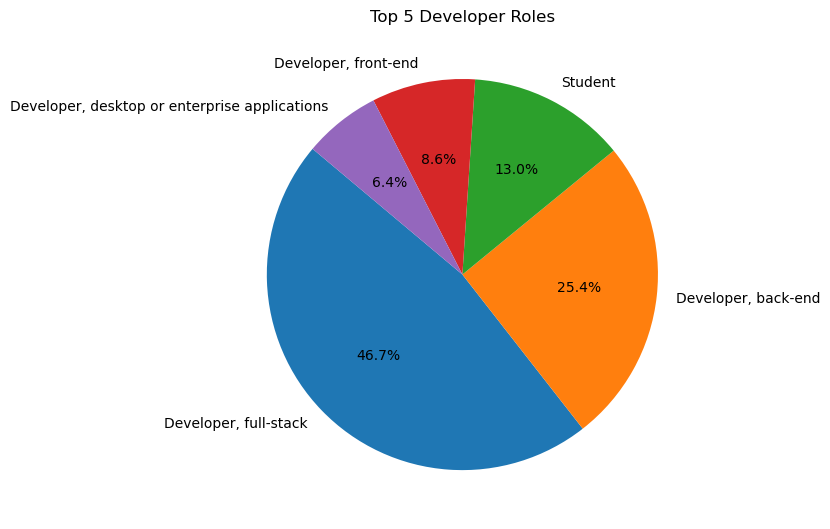

In [11]:
# Create pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_roles.values,
    labels=top_roles.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 Developer Roles')

plt.tight_layout()
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use

The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.

In [12]:
# Select the operating system column and remove missing values

os_df = df[['OpSysProfessional use']].dropna()

# Display first few rows
print(os_df.head())

  OpSysProfessional use
1                 MacOS
2               Windows
6                 MacOS
7                 MacOS
8                 MacOS


In [13]:
# Split multiple operating systems into separate rows

os_exploded = os_df.assign(
    **{
        'OpSysProfessional use':
        os_df['OpSysProfessional use'].str.split(';')
    }
).explode('OpSysProfessional use')

In [14]:
# Count frequency of each operating system

top_os = (
    os_exploded['OpSysProfessional use']
    .value_counts()
    .head(5)
)

print(top_os)

OpSysProfessional use
Windows                              27918
MacOS                                18625
Ubuntu                               16237
Windows Subsystem for Linux (WSL)     9859
Debian                                5327
Name: count, dtype: int64


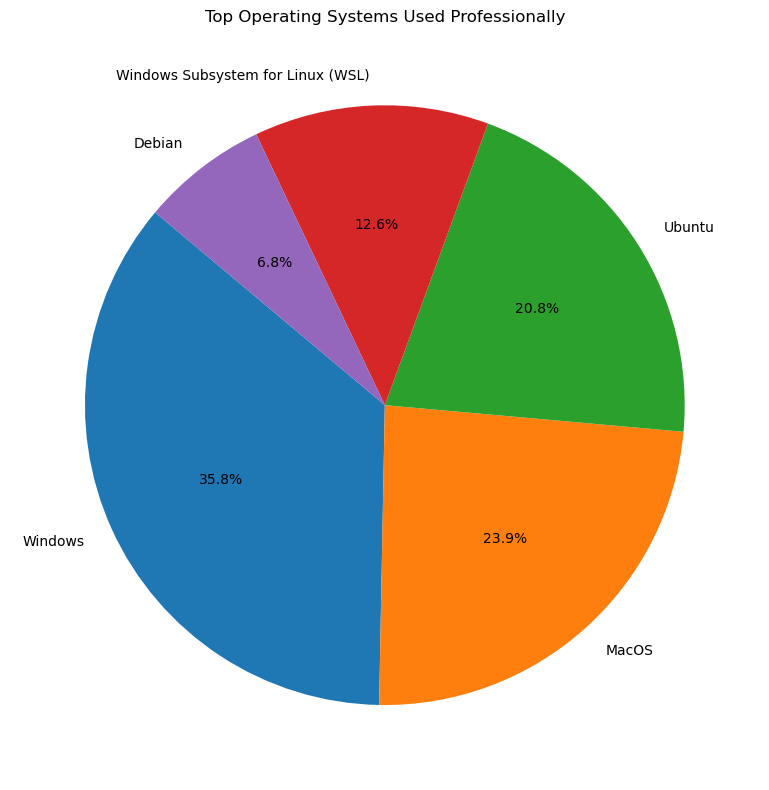

In [15]:
# Create pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_os.values,
    labels=top_os.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top Operating Systems Used Professionally')

plt.tight_layout()
plt.show()

### Task 2: Additional Visualizations and Comparisons

##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With

The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.

In [16]:
# Select the LanguageHaveWorkedWith column and remove missing values

lang_df = df[['LanguageHaveWorkedWith']].dropna()

# Display first few rows
print(lang_df.head())

                              LanguageHaveWorkedWith
1  Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2                                                 C#
3  C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...
4            C++;HTML/CSS;JavaScript;Lua;Python;Rust
5  Bash/Shell (all shells);HTML/CSS;Java;JavaScri...


In [17]:
# Split multiple languages into separate rows

lang_exploded = lang_df.assign(
    LanguageHaveWorkedWith=
    lang_df['LanguageHaveWorkedWith'].str.split(';')
).explode('LanguageHaveWorkedWith')

In [18]:
# Count frequency of each programming language

top_languages = (
    lang_exploded['LanguageHaveWorkedWith']
    .value_counts()
    .head(5)
)

print(top_languages)

LanguageHaveWorkedWith
JavaScript    37492
HTML/CSS      31816
Python        30719
SQL           30682
TypeScript    23150
Name: count, dtype: int64


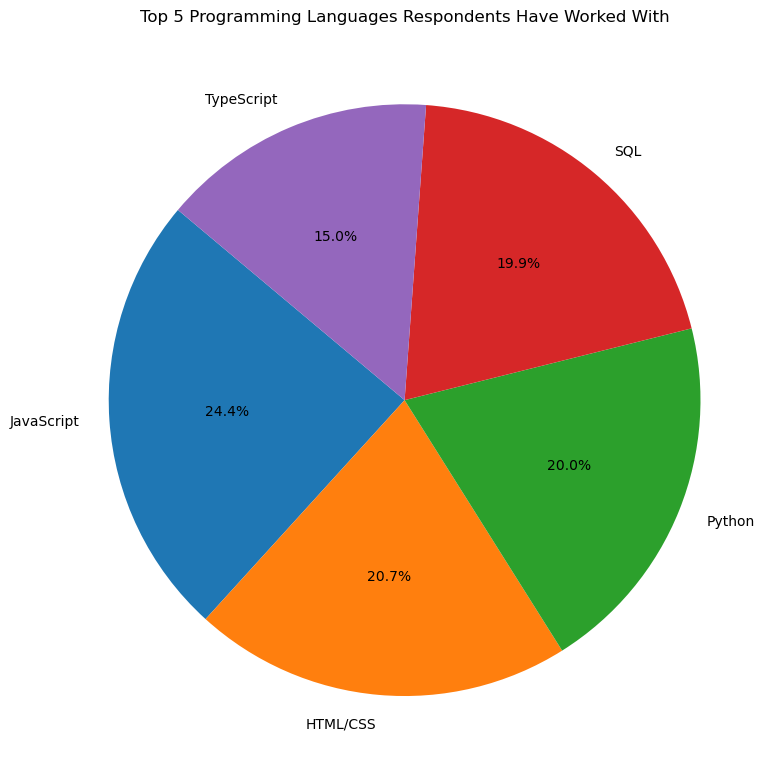

In [19]:
# Create pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_languages.values,
    labels=top_languages.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 Programming Languages Respondents Have Worked With')

plt.tight_layout()
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use

Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.

In [20]:
# Select the collaboration tools column and remove missing values

tools_df = df[['NEWCollabToolsHaveWorkedWith']].dropna()

# Display first few rows
print(tools_df.head())

          NEWCollabToolsHaveWorkedWith
1  PyCharm;Visual Studio Code;WebStorm
2                        Visual Studio
4                                  Vim
5    Nano;Vim;Visual Studio Code;Xcode
6                              RStudio


In [21]:
# Split multiple collaboration tools into separate rows

tools_exploded = tools_df.assign(
    NEWCollabToolsHaveWorkedWith=
    tools_df['NEWCollabToolsHaveWorkedWith'].str.split(';')
).explode('NEWCollabToolsHaveWorkedWith')

In [22]:
# Count frequency of each collaboration tool

top_tools = (
    tools_exploded['NEWCollabToolsHaveWorkedWith']
    .value_counts()
    .head(5)
)

print(top_tools)

NEWCollabToolsHaveWorkedWith
Visual Studio Code    42751
Visual Studio         17021
IntelliJ IDEA         15555
Notepad++             13874
Vim                   12523
Name: count, dtype: int64


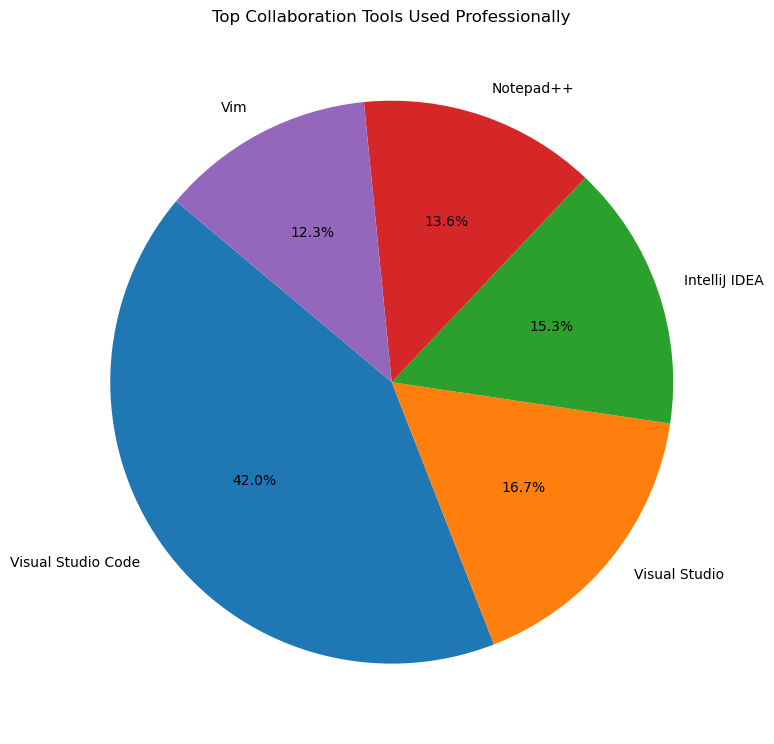

In [23]:
# Create pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_tools.values,
    labels=top_tools.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top Collaboration Tools Used Professionally')

plt.tight_layout()
plt.show()

### Task 3: Analyzing and Interpreting Composition

In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.

##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages

The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.

In [24]:
# Select the LanguageAdmired column and remove missing values

admired_df = df[['LanguageAdmired']].dropna()

# Display first few rows
print(admired_df.head())

                                     LanguageAdmired
1  Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2                                                 C#
3  HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...
4                 C++;HTML/CSS;JavaScript;Lua;Python
5  Bash/Shell (all shells);HTML/CSS;Java;JavaScri...


In [25]:
# Split multiple admired languages into separate rows

admired_exploded = admired_df.assign(
    LanguageAdmired=
    admired_df['LanguageAdmired'].str.split(';')
).explode('LanguageAdmired')

In [26]:
# Count frequency of admired languages

top_admired_languages = (
    admired_exploded['LanguageAdmired']
    .value_counts()
    .head(5)
)

print(top_admired_languages)

LanguageAdmired
JavaScript    21869
Python        20774
SQL           20692
HTML/CSS      19851
TypeScript    16079
Name: count, dtype: int64


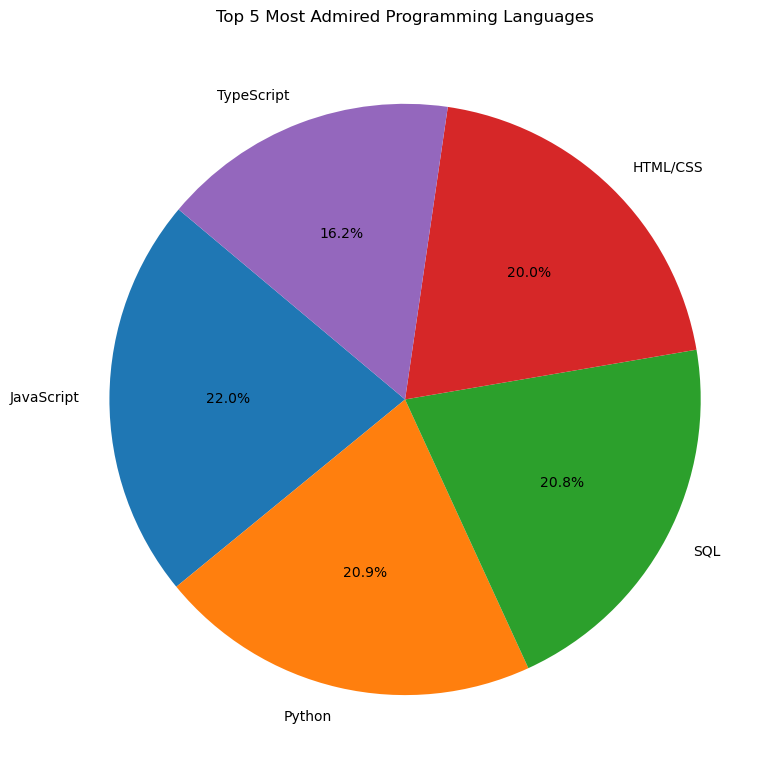

In [27]:
# Create pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_admired_languages.values,
    labels=top_admired_languages.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 Most Admired Programming Languages')

plt.tight_layout()
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development

Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.

In [28]:
# Select the AI tools column and remove missing values

ai_df = df[['AIToolCurrently Using']].dropna()

# Display first few rows
print(ai_df.head())

                                AIToolCurrently Using
3   Learning about a codebase;Project planning;Wri...
5             Writing code;Debugging and getting help
7   Writing code;Debugging and getting help;Search...
9                                  Search for answers
10  Learning about a codebase;Writing code;Documen...


In [29]:
# Split multiple AI tools into separate rows

ai_exploded = ai_df.assign(
    **{
        'AIToolCurrently Using':
        ai_df['AIToolCurrently Using'].str.split(';')
    }
).explode('AIToolCurrently Using')

In [30]:
# Count frequency of AI tools

top_ai_tools = (
    ai_exploded['AIToolCurrently Using']
    .value_counts()
    .head(5)
)

print(top_ai_tools)

AIToolCurrently Using
Writing code                            29486
Search for answers                      24295
Debugging and getting help              20404
Documenting code                        14439
Generating content or synthetic data    12538
Name: count, dtype: int64


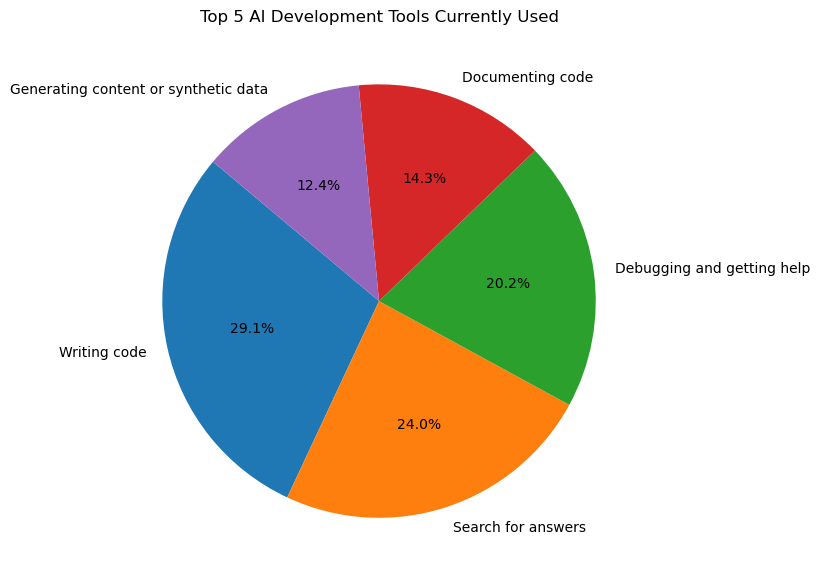

In [31]:
# Create pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_ai_tools.values,
    labels=top_ai_tools.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 AI Development Tools Currently Used')

plt.tight_layout()
plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks

The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.

In [32]:
# Select the WebframeWantToWorkWith column and remove missing values

web_df = df[['WebframeWantToWorkWith']].dropna()

# Display first few rows
print(web_df.head())

             WebframeWantToWorkWith
1  Express;Htmx;Node.js;React;Remix
2                      ASP.NET CORE
3      jQuery;Next.js;Node.js;React
5                           Node.js
7                     Next.js;React


In [33]:
# Split multiple web frameworks into separate rows

web_exploded = web_df.assign(
    WebframeWantToWorkWith=
    web_df['WebframeWantToWorkWith'].str.split(';')
).explode('WebframeWantToWorkWith')

In [34]:
# Count frequency of each web framework

top_frameworks = (
    web_exploded['WebframeWantToWorkWith']
    .value_counts()
    .head(5)
)

print(top_frameworks)

WebframeWantToWorkWith
React           15404
Node.js         14735
Next.js          8507
Vue.js           7604
ASP.NET CORE     6905
Name: count, dtype: int64


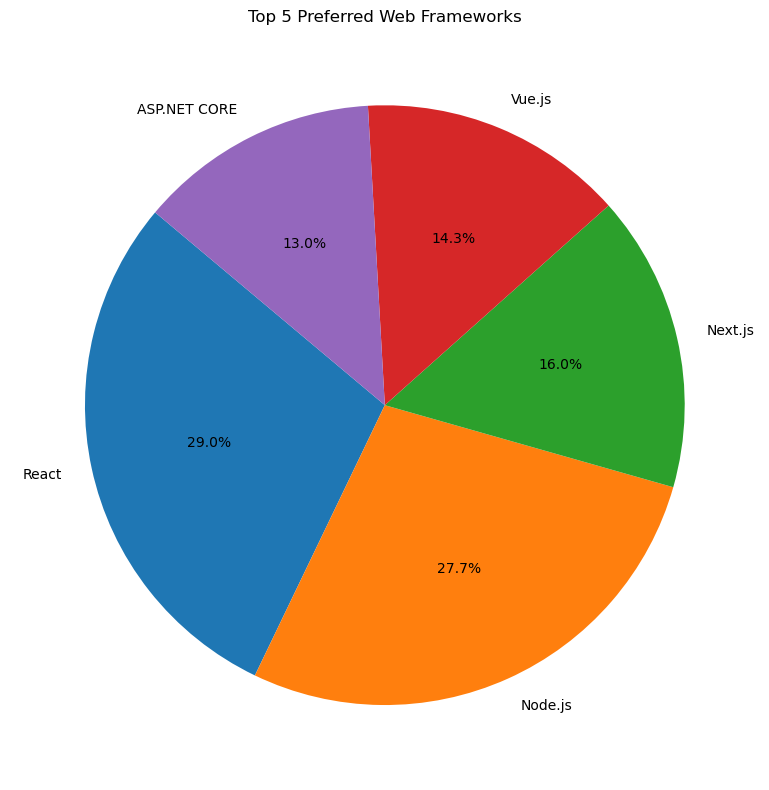

In [35]:
# Create pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_frameworks.values,
    labels=top_frameworks.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 Preferred Web Frameworks')

plt.tight_layout()
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies

Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.

In [36]:
# Select the EmbeddedWantToWorkWith column and remove missing values

embedded_df = df[['EmbeddedWantToWorkWith']].dropna()

# Display first few rows
print(embedded_df.head())

   EmbeddedWantToWorkWith
2             Rasberry Pi
4       CMake;Rasberry Pi
5             Rasberry Pi
15            Rasberry Pi
20            Rasberry Pi


In [37]:
# Split multiple embedded technologies into separate rows

embedded_exploded = embedded_df.assign(
    EmbeddedWantToWorkWith=
    embedded_df['EmbeddedWantToWorkWith'].str.split(';')
).explode('EmbeddedWantToWorkWith')

In [38]:
# Count frequency of each embedded technology

top_embedded = (
    embedded_exploded['EmbeddedWantToWorkWith']
    .value_counts()
    .head(5)
)

print(top_embedded)

EmbeddedWantToWorkWith
Rasberry Pi    9792
Arduino        6482
GNU GCC        5870
CMake          4693
Cargo          4567
Name: count, dtype: int64


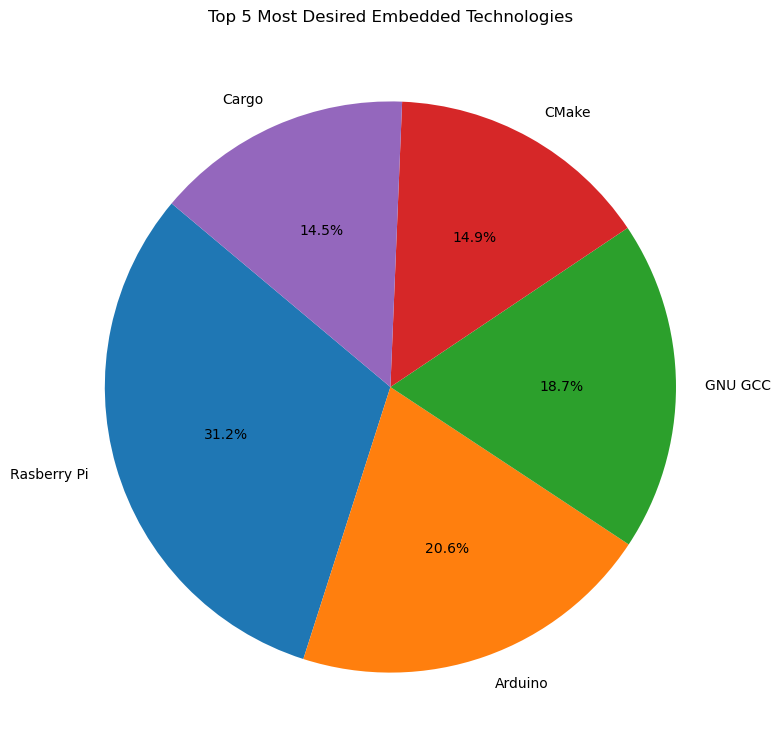

In [39]:
# Create pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_embedded.values,
    labels=top_embedded.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 Most Desired Embedded Technologies')

plt.tight_layout()
plt.show()

### Summary

After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.